# Assignment 4: Python Statistics and Plotting Tutorial

**Course:** BSGP 7030

This notebook is following the SciPy Lectures statistical tutorial.

Each cell has been entered in manually, with comments included to track the understanding of the code and interpretation of a given result.

In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pandas

print("Everything imported successfully!")

Everything imported successfully!


## 3.1.1 Data Representation and Interaction

In this section, I will load a dataset containing brain size, IQ, height, weight, and gender measurements. Each row represents one individual, and each column represents a measured variable.

Note: Below includes the additional code that shows na_values="." becuase the weight of the second individual is missing in the CSV file. If we don’t specify the missing value (NA = not available) marker, we will not be able to do statistical analysis.

In [2]:
# Load the brain size dataset into a pandas DataFrame.
# The semicolon (;) is used as the column separator,
# and "." values are interpreted as missing (NaN) data.

brain_data = pd.read_csv(
    "../data/brain_size.csv",
    sep=";",
    na_values="."
)

brain_data

,Unnamed: 0,Gender,FSIQ,VIQ,PIQ,Weight,Height,MRI_Count
0,1,Female,133,132,124,118.0,64.5,816932
1,2,Male,140,150,124,NaN,72.5,1001121
2,3,Male,139,123,150,143.0,73.3,1038437
3,4,Male,133,129,128,172.0,68.8,965353
4,5,Female,137,132,134,147.0,65.0,951545
5,6,Female,99,90,110,146.0,69.0,928799
6,7,Female,138,136,131,138.0,64.5,991305
7,8,Female,92,90,98,175.0,66.0,854258
8,9,Male,89,93,84,134.0,66.3,904858
9,10,Male,133,114,147,172.0,68.8,955466


In [3]:
# The DataFrame organizes the observations into rows
# and variables into columns, making the dataset easier
# to inspect, summarize, and analyze.

Creating from arrays: A pandas.DataFrame can also be seen as a dictionary of 1D 'series', eg arrays or lists. If we have 3 numpy arrays:

In [4]:
t = np.linspace(-6, 6, 20)
sin_t = np.sin(t)
cos_t = np.cos(t)

We can expose them as a pandas.DataFrame:

**Important that you add "Import Pandas" to the first section of import functions.

In [5]:
pandas.DataFrame({'t': t, 'sin': sin_t, 'cos': cos_t})

,t,sin,cos
0,-6.000000,0.279415,0.960170
1,-5.368421,0.792419,0.609977
2,-4.736842,0.999701,0.024451
3,-4.105263,0.821291,-0.570509
4,-3.473684,0.326021,-0.945363
5,-2.842105,-0.295030,-0.955488
6,-2.210526,-0.802257,-0.596979
7,-1.578947,-0.999967,-0.008151
8,-0.947368,-0.811882,0.583822
9,-0.315789,-0.310567,0.950551


## Manipulating Data

data is a pandas.DataFrame, That resembles R's dataframe:

In [6]:
brain_data.shape    # 40 rows and 8 columns
(40, 8)

(40, 8)

In [7]:
brain_data.columns  # It has columns   

Index(['Unnamed: 0', 'Gender', 'FSIQ', 'VIQ', 'PIQ', 'Weight', 'Height',
       'MRI_Count'],
      dtype='object')

In [8]:
print(brain_data['Gender']) #Columns can be addressed by name

0     Female
1       Male
2       Male
3       Male
4     Female
5     Female
6     Female
7     Female
8       Male
9       Male
10    Female
11      Male
12      Male
13    Female
14    Female
15    Female
16    Female
17      Male
18    Female
19      Male
20      Male
21      Male
22    Female
23      Male
24    Female
25      Male
26    Female
27      Male
28    Female
29    Female
30    Female
31      Male
32      Male
33      Male
34    Female
35    Female
36      Male
37    Female
38      Male
39      Male
Name: Gender, dtype: object


Simpler selector

In [9]:
brain_data[brain_data['Gender'] == 'Female']['VIQ'].mean()

np.float64(109.45)

groupby: splitting a dataframe on values of categorical variables:

In [10]:
groupby_gender = brain_data.groupby('Gender')

for gender, value in groupby_gender['VIQ']:

    print((gender, value.mean()))

('Female', np.float64(109.45))
('Male', np.float64(115.25))


groupby_gender is a powerful object that exposes many operations on the resulting group of dataframes:

In [11]:
groupby_gender.mean()

,Unnamed: 0,FSIQ,VIQ,PIQ,Weight,Height,MRI_Count
Gender,,,,,,,
Female,19.65,111.9,109.45,110.45,137.200000,65.765000,862654.6
Male,21.35,115.0,115.25,111.60,166.444444,71.431579,954855.4


Exercise

    What is the mean value for VIQ for the full population? 112.35

    How many males/females were included in this study? 20 and 20

    Hint use ‘tab completion’ to find out the methods that can be called, instead of ‘mean’ in the above example.

    What is the average value of MRI counts expressed in log units, for males and females?



In [12]:
brain_data['VIQ'].mean()

np.float64(112.35)

In [13]:
brain_data['VIQ'].count

<bound method Series.count of 0     132
1     150
2     123
3     129
4     132
5      90
6     136
7      90
8      93
9     114
10    129
11    150
12    129
13    120
14    100
15     71
16    132
17     96
18    112
19     77
20     83
21    107
22    129
23    145
24     86
25    145
26     90
27     96
28     83
29    126
30    126
31    145
32     96
33     96
34     90
35    129
36    150
37     86
38     90
39     91
Name: VIQ, dtype: int64>

In [14]:
groupby_gender['VIQ'].count()

Gender
Female    20
Male      20
Name: VIQ, dtype: int64

Type: "data['VIQ']." and then press tab and you will see the different functions that you can run like mean.

**Interpretation:**
The average VIQ for all participants is 112.35.
Males have a slightly higher average VIQ than females
in this sample, although this alone does not indicate
whether the difference is statistically significant.

## Plotting Data

Pandas comes with some plotting tools (pandas.tools.plotting, using matplotlib behind the scene) to display statistics of the data in dataframes:

In [15]:
from pandas import plotting

**Note that the instructions that we were given we were told to type pands.tools rather than just pandas but this is an older model. 

array([[<Axes: xlabel='Weight', ylabel='Weight'>,
        <Axes: xlabel='Height', ylabel='Weight'>,
        <Axes: xlabel='MRI_Count', ylabel='Weight'>],
       [<Axes: xlabel='Weight', ylabel='Height'>,
        <Axes: xlabel='Height', ylabel='Height'>,
        <Axes: xlabel='MRI_Count', ylabel='Height'>],
       [<Axes: xlabel='Weight', ylabel='MRI_Count'>,
        <Axes: xlabel='Height', ylabel='MRI_Count'>,
        <Axes: xlabel='MRI_Count', ylabel='MRI_Count'>]], dtype=object)

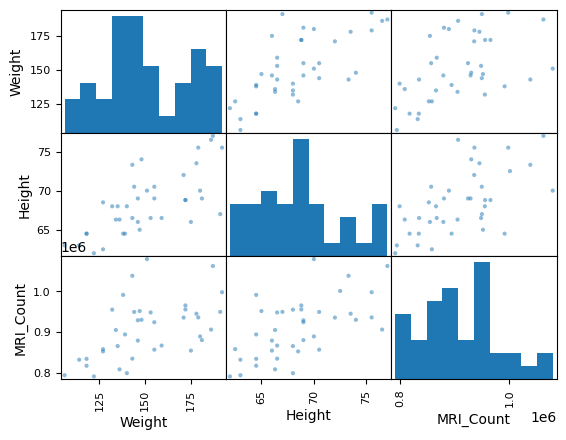

In [16]:
plotting.scatter_matrix(brain_data[['Weight', 'Height', 'MRI_Count']])

array([[<Axes: xlabel='PIQ', ylabel='PIQ'>,
        <Axes: xlabel='VIQ', ylabel='PIQ'>,
        <Axes: xlabel='FSIQ', ylabel='PIQ'>],
       [<Axes: xlabel='PIQ', ylabel='VIQ'>,
        <Axes: xlabel='VIQ', ylabel='VIQ'>,
        <Axes: xlabel='FSIQ', ylabel='VIQ'>],
       [<Axes: xlabel='PIQ', ylabel='FSIQ'>,
        <Axes: xlabel='VIQ', ylabel='FSIQ'>,
        <Axes: xlabel='FSIQ', ylabel='FSIQ'>]], dtype=object)

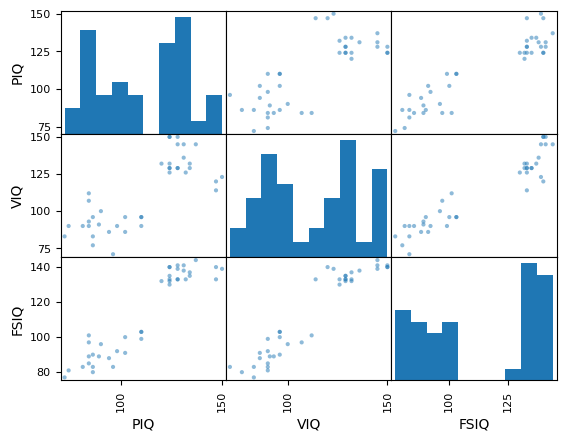

In [17]:
plotting.scatter_matrix(brain_data[['PIQ', 'VIQ', 'FSIQ']])

## 3.1.2. Hypothesis testing: comparing two groups

For simple statistivcal tests, we will use the scipy.stats sub-module of scipy:

In [18]:
from scipy import stats

### Student's t-test: the simplest statistical test

#### 1-sample t-test: testing the value of a population mean

scipy.stats.ttest_1samp() tests if the population mean of data is likely to be equal to a given value (technically if observations are drawn from a Gaussian distributions of given population mean). It returns the T statistic, and the p-value (see the function’s help):

In [19]:
stats.ttest_1samp(brain_data['VIQ'], 0)

TtestResult(statistic=np.float64(30.08809997084933), pvalue=np.float64(1.3289196468727879e-28), df=np.int64(39))

With a p-value of 10^-28 we can claim that the population mean for the IQ (VIQ measure) is not 0. 

#### 2-sample t-test: testing for difference acress populations

We have seen above that the mean VIQ in the male and female populations were different. To test if this is significant, we do a 2-sample t-test with scipy.stats.ttest_ind():

In [20]:
female_viq = brain_data[brain_data['Gender'] == 'Female']['VIQ']
male_viq = brain_data[brain_data['Gender'] == 'Male']['VIQ']
stats.ttest_ind(female_viq, male_viq)

TtestResult(statistic=np.float64(-0.7726161723275012), pvalue=np.float64(0.44452876778583217), df=np.float64(38.0))

### Paired tests: repeated measurements on the same individuals

PIQ, VIQ, and FSIQ give 3 measures of IQ. Let us test if FISQ and PIQ are significantly different. We can use a 2 sample test:

In [21]:
stats.ttest_ind(brain_data['FSIQ'], brain_data['PIQ'])

TtestResult(statistic=np.float64(0.465637596380964), pvalue=np.float64(0.6427725009414841), df=np.float64(78.0))

The problem with this approach is that it forgets that there are links between observations: FSIQ and PIQ are measured on the same individuals. Thus the variance due to inter-subject variability is confounding, and can be removed, using a “paired test”, or “repeated measures test”:v

In [22]:
stats.ttest_rel(brain_data['FSIQ'], brain_data['PIQ'])

TtestResult(statistic=np.float64(1.7842019405859857), pvalue=np.float64(0.08217263818364236), df=np.int64(39))

This is equivalent to a 1-sample test on the difference:

In [23]:
stats.ttest_1samp(brain_data['FSIQ'] - brain_data['PIQ'], 0)

TtestResult(statistic=np.float64(1.7842019405859857), pvalue=np.float64(0.08217263818364236), df=np.int64(39))

T-tests assume Gaussian errors. We can use a Wilcoxon signed-rank test, that relaxes this assumption:

In [24]:
stats.wilcoxon(brain_data['FSIQ'], brain_data['PIQ'])

WilcoxonResult(statistic=np.float64(274.5), pvalue=np.float64(0.10659492713506856))

**Note: The corresponding test in the non paired case is the Mann–Whitney U test, scipy.stats.mannwhitneyu(). 

Exercise

    Test the difference between weights in males and females.
    Use non parametric statistics to test the difference between VIQ in males and females.

Conclusion: we find that the data does not support the hypothesis that males and females have different VIQ.


In [25]:
# Select the available weight measurements for females and males.
# dropna() removes missing weight values before running the test.

female_weight = brain_data[brain_data['Gender'] == 'Female']['Weight'].dropna()
male_weight = brain_data[brain_data['Gender'] == 'Male']['Weight'].dropna()

# Use an independent two-sample t-test to test whether
# mean weight differs between males and females.

stats.ttest_ind(female_weight, male_weight)

TtestResult(statistic=np.float64(-4.870950921940696), pvalue=np.float64(2.227293018362118e-05), df=np.float64(36.0))

What does this mean: The p-value is less than 0.05, so we reject the null hypothesis.
+ The data provide evidence that mean weight differs significantly
+ and between males and females in this sample.

In [26]:
# Use the Mann–Whitney U test as the nonparametric alternative
# to the independent two-sample t-test.

female_viq = brain_data[brain_data['Gender'] == 'Female']['VIQ']
male_viq = brain_data[brain_data['Gender'] == 'Male']['VIQ']

stats.mannwhitneyu(female_viq, male_viq, alternative='two-sided')

MannwhitneyuResult(statistic=np.float64(164.5), pvalue=np.float64(0.3422886868727315))

Meaning:
+ The p-value is greater than 0.05, so we fail to reject
+ the null hypothesis. The data do not provide sufficient
+ evidence that VIQ differs between males and females.

## 3.1.3 Linear models, multiple factors, and analysis of variance

### “formulas” to specify statistical models in Python

#### A simple linear regression

Given two set of observations, x and y, we want to test the hypothesis that y is a linear function of x. In other terms:|

#### y = x * \textit{coef} + \textit{intercept} + e

where e is observation noise. We will use the statsmodels module to:
    1. Fit a linear model. We will use the simplest strategy, ordinary least squares (OLS).
    2. Test that coef is non zero.

First, we generate simulated data according to the model:
>>import numpy as np has already been initiated at top of notebook

In [27]:
x = np.linspace(-5, 5, 20)

np.random.seed(1)

# normal distributed noise

y = -5 + 3*x + 4 * np.random.normal(size=x.shape)

# Create a data frame containing all the relevant variables

brain_data = pandas.DataFrame({'x': x, 'y': y})

Then we specify an OLS model and fit it:

In [28]:
from statsmodels.formula.api import ols

model = ols("y ~ x", brain_data).fit()

We can inspect the various statistics derived from the fit:

In [29]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.804
Model:                            OLS   Adj. R-squared:                  0.794
Method:                 Least Squares   F-statistic:                     74.03
Date:                Mon, 27 Jul 2026   Prob (F-statistic):           8.56e-08
Time:                        18:09:41   Log-Likelihood:                -57.988
No. Observations:                  20   AIC:                             120.0
Df Residuals:                      18   BIC:                             122.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -5.5335      1.036     -5.342      0.0

#### Terminology:

Statsmodels uses a statistical terminology: the y variable in statsmodels is called ‘endogenous’ while the x variable is called exogenous. This is discussed in more detail here.

To simplify, y (endogenous) is the value you are trying to predict, while x (exogenous) represents the features you are using to make the prediction.

#### Exercise

Retrieve the estimated parameters from the model above. Hint: use tab-completion to find the relevent attribute.

#### Categorical variables: comparing groups or multiple categories

Let us go back the data on brain size:

In [30]:
brain_data = pandas.read_csv('../data/brain_size.csv', sep=';', na_values=".")

We can write a comparison between IQ of male and female using a linear model:

In [31]:
model = ols("VIQ ~ Gender + 1", brain_data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    VIQ   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                 -0.010
Method:                 Least Squares   F-statistic:                    0.5969
Date:                Mon, 27 Jul 2026   Prob (F-statistic):              0.445
Time:                        18:09:41   Log-Likelihood:                -182.42
No. Observations:                  40   AIC:                             368.8
Df Residuals:                      38   BIC:                             372.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        109.4500      5.308     20.

#### Tips on specifying model

Forcing categorical: the ‘Gender’ is automatically detected as a categorical variable, and thus each of its different values are treated as different entities.

An integer column can be forced to be treated as categorical using:

In [32]:
model = ols('VIQ ~ C(Gender)', brain_data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    VIQ   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                 -0.010
Method:                 Least Squares   F-statistic:                    0.5969
Date:                Mon, 27 Jul 2026   Prob (F-statistic):              0.445
Time:                        18:09:41   Log-Likelihood:                -182.42
No. Observations:                  40   AIC:                             368.8
Df Residuals:                      38   BIC:                             372.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept           109.4500      5.30

In [33]:
brain_data.columns

Index(['Unnamed: 0', 'Gender', 'FSIQ', 'VIQ', 'PIQ', 'Weight', 'Height',
       'MRI_Count'],
      dtype='object')

**Intercept**: We can remove the intercept using - 1 in the formula, or force the use of an intercept using + 1.

By default, statsmodels treats a categorical variable with K possible values as K-1 ‘dummy’ boolean variables (the last level being absorbed into the intercept term). This is almost always a good default choice - however, it is possible to specify different encodings for categorical variables (http://statsmodels.sourceforge.net/devel/contrasts.html).

#### **Link to t-tests between different FSIQ and PIQ**

To compare different types of IQ, we need to create a “long-form” table, listing IQs, where the type of IQ is indicated by a categorical variable:

In [34]:
brain_data_fisq = pandas.DataFrame({'iq': brain_data['FSIQ'], 'type': 'fsiq'})
brain_data_piq = pandas.DataFrame({'iq': brain_data['PIQ'], 'type': 'piq'})
brain_data_long = pandas.concat((brain_data_fisq, brain_data_piq))
print(brain_data_long)  

     iq  type
0   133  fsiq
1   140  fsiq
2   139  fsiq
3   133  fsiq
4   137  fsiq
..  ...   ...
35  128   piq
36  124   piq
37   94   piq
38   74   piq
39   89   piq

[80 rows x 2 columns]


In [35]:
model = ols("iq ~ type", brain_data_long).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                     iq   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.010
Method:                 Least Squares   F-statistic:                    0.2168
Date:                Mon, 27 Jul 2026   Prob (F-statistic):              0.643
Time:                        18:09:41   Log-Likelihood:                -364.35
No. Observations:                  80   AIC:                             732.7
Df Residuals:                      78   BIC:                             737.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept     113.4500      3.683     30.807      

We can see that we retrieve the same values for t-test and corresponding p-values for the effect of the type of iq than the previous t-test:

In [36]:
stats.ttest_ind(brain_data['FSIQ'], brain_data['PIQ'])

TtestResult(statistic=np.float64(0.465637596380964), pvalue=np.float64(0.6427725009414841), df=np.float64(78.0))

### 3.1.3.2. Multiple Regression: including multiple factors

Consider a linear model explaining a variable z (the dependent variable) with 2 variables x and y:

#### **z = x \, c_1 + y \, c_2 + i + e**

Such a model can be seen in 3D as fitting a plane to a cloud of (x, y, z) points.



**Example: the iris data** (examples/iris.csv)

Sepal and petal size tend to be related: bigger flowers are bigger! But is there in addition a systematic effect of species? 

In [37]:
iris_data = pd.read_csv(
    "../data/iris.csv",
    header=None,
    names=[
        "sepal_length",
        "sepal_width",
        "petal_length",
        "petal_width",
        "name"
    ]
)

model = ols(
    "sepal_width ~ name + petal_length",
    data=iris_data
).fit()
model = ols('sepal_width ~ name + petal_length', iris_data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            sepal_width   R-squared:                       0.478
Model:                            OLS   Adj. R-squared:                  0.468
Method:                 Least Squares   F-statistic:                     44.63
Date:                Mon, 27 Jul 2026   Prob (F-statistic):           1.58e-20
Time:                        18:09:41   Log-Likelihood:                -38.185
No. Observations:                 150   AIC:                             84.37
Df Residuals:                     146   BIC:                             96.41
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

**Note:** remember that the columns in your csv will have to be appropriately named or code modified to incoorporate headers. 

### 3.1.3.3. Post-hoc hypothesis testing: analysis of variance (ANOVA)

In the above iris example, we wish to test if the petal length is different between versicolor and virginica, after removing the effect of sepal width. This can be formulated as testing the difference between the coefficient associated to versicolor and virginica in the linear model estimated above (it is an Analysis of Variance, ANOVA). For this, we write a vector of ‘contrast’ on the parameters estimated: we want to test "name[T.versicolor] - name[T.virginica]", with an F-test:

In [38]:
print(model.f_test([0, 1, -1, 0]))

<F test: F=3.2453353465743553, p=0.07369058781700252, df_denom=146, df_num=1>


Is this difference significant?

Ths is not significant as the p value is not below 0.05.

**Exercise**
Going back to the brain size + IQ data, test if the VIQ of male and female are different after removing the effect of brain size, height and weight.


## 3.1.4. More visualization: seaborn for statistical exploration

Seaborn combines simple statistical fits with plotting on pandas dataframes.

Let us consider a data giving wages and many other personal information on 500 individuals (Berndt, ER. The Practice of Econometrics. 1991. NY: Addison-Wesley).

The full code loading and plotting of the wages data is found in corresponding example.

Load the brain size dataset into a pandas DataFrame.
The semicolon (;) is used as the column separator,
and "." values are interpreted as missing (NaN) data.

In [39]:
#You have already loaded pandas
columns = [
    "education",
    "south",
    "sex",
    "experience",
    "union",
    "wage",
    "age",
    "race",
    "occupation",
    "sector",
    "married"
]

education_wages = pd.read_csv(
    "../data/CPS_85_Wages.txt",
    sep=r"\s+",
    skiprows=27,
    skipfooter=5,
    names=columns,
    engine="python"
)

print(education_wages.head())

   education  south  sex  experience  union  wage  age  race  occupation  \
0          8      0    1          21      0  5.10   35     2           6   
1          9      0    1          42      0  4.95   57     3           6   
2         12      0    0           1      0  6.67   19     3           6   
3         12      0    0           4      0  4.00   22     3           6   
4         12      0    0          17      0  7.50   35     3           6   

   sector  married  
0       1        1  
1       1        1  
2       1        0  
3       0        0  
4       0        1  


**Interpretation:**
The descriptive statistics summarize each variable by reporting
the count, mean, standard deviation, minimum, maximum,
and quartiles (25%, 50%, and 75%).

These statistics provide an initial understanding of the data,
including the typical values, variability, and potential outliers,
before proceeding with additional statistical analyses.

### Pairplot: scatter matrices

We can easily have an intuition on the interactions between continuous variables using seaborn.pairplot() to display a scatter matrix:
You have already imported **seaborn**

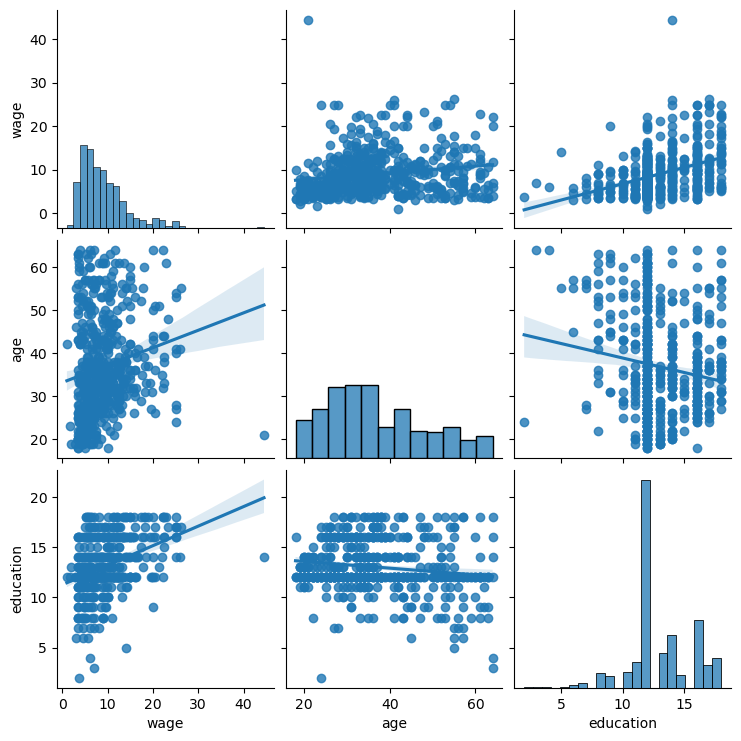

In [40]:
sns.pairplot(education_wages,
             vars=['wage', 'age', 'education'],
             kind='reg')

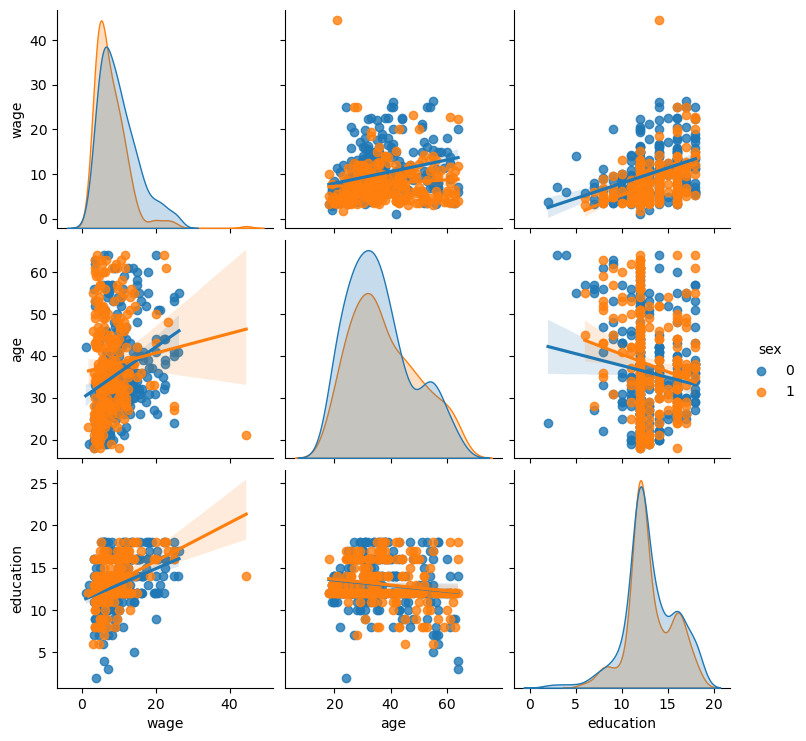

In [41]:
sns.pairplot(education_wages, vars=['wage', 'age', 'education'],kind='reg', hue='sex')  

**look and feel matplotlib settings**
Seaborn changes the default of matplotlib figures to achieve a more “modern”, “excel-like” look. It does that upon import. You can reset the default using:

In [42]:
from matplotlib import pyplot as plt
plt.rcdefaults()

To switch back to seaborn settings, or understand better styling in seaborn, see the relevent section of the seaborn documentation. 

### 3.1.4.2. lmplot: plotting a univariate regression

A regression capturing the relation between one variable and another, eg wage and eduction, can be plotted using seaborn.lmplot():

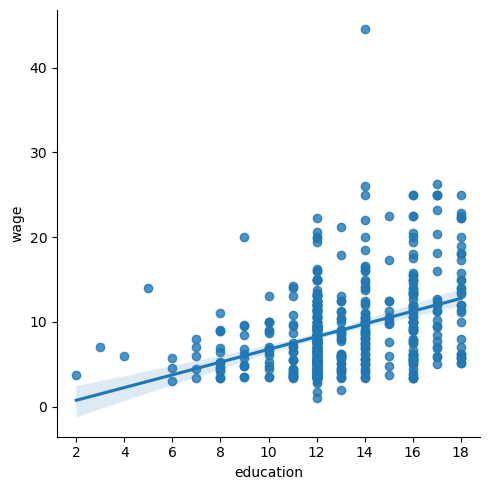

In [43]:
sns.lmplot(y='wage', x='education', data=education_wages)  

**Robust regression**
Given that, in the above plot, there seems to be a couple of data points that are outside of the main cloud to the right, they might be outliers, not representative of the population, but driving the regression.
To compute a regression that is less sentive to outliers, one must use a robust model. This is done in seaborn using robust=True in the plotting functions, or in statsmodels by replacing the use of the OLS by a “Robust Linear Model”, statsmodels.formula.api.rlm().

### 3.1.5. Testing for interactions

Do wages increase more with education for males than females?

The plot above is made of two different fits. We need to formulate a single model that tests for a variance of slope across the two populations. This is done via an “interaction”. 

In [44]:
result = smf.ols(formula='wage ~ education + sex + education * sex', data=education_wages).fit()
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.190
Model:                            OLS   Adj. R-squared:                  0.186
Method:                 Least Squares   F-statistic:                     41.50
Date:                Mon, 27 Jul 2026   Prob (F-statistic):           4.24e-24
Time:                        18:09:45   Log-Likelihood:                -1575.0
No. Observations:                 534   AIC:                             3158.
Df Residuals:                     530   BIC:                             3175.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         1.1046      1.314      0.841

Can we conclude that education benefits males more than females?

No we can not becuase the significance of wages is dependant on sex but not sex and education.

Although education and sex are individually associated with wages, the 
education-by-sex interaction is not statistically significant 
(p = 0.273). Therefore, there is insufficient evidence that the effect 
of education on wages differs between males and females.

Take home messages
+ Hypothesis testing and p-values give you the significance of an effect / difference.
+ Formulas (with categorical variables) enable you to express rich links in your data.
+ Visualizing your data and fitting simple models give insight into the data.
+ Conditionning (adding factors that can explain all or part of the variation) is an important modeling aspect that changes the interpretation.